In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import pandas as pd
from _notebook_init import CONFIG_PATH, DATA_PROCESSED, DATA_RAW

from weather_markov.preprocessing.aggregator import DecadeAggregator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
raw_df = pd.read_csv(
    DATA_RAW / "data.csv",
    comment="#",
    delimiter=";",
    index_col=False,
    parse_dates=[0],
    date_format="%d.%m.%Y %H:%M",
    low_memory=False,
)
raw_df.head()

,Local time in Moscow,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,2026-03-07 13:00:00,1.0,750.0,NaN,NaN,83.0,Wind blowing from the west,2,NaN,NaN,...,NaN,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-07 12:00:00,0.7,749.2,763.2,-0.9,82.0,Wind blowing from the west-northwest,2,NaN,NaN,...,NaN,NaN,20.0,-2.1,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-07 11:00:00,1.0,749.0,NaN,NaN,73.0,Wind blowing from the west,2,NaN,NaN,...,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-07 10:00:00,1.5,749.0,NaN,NaN,69.0,Wind blowing from the west,1,NaN,NaN,...,NaN,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-07 09:00:00,-0.8,750.1,764.3,-2.0,80.0,Wind blowing from the west,1,NaN,NaN,...,Altocumulus translucidus at a single level.,"Cirrus fibratus, sometimes uncinus, not progre...",20.0,-3.9,No precipitation,12.0,NaN,NaN,Even layer of compact or wet snow covering gro...,47.0


In [37]:
aggregator = DecadeAggregator()
decade_df = aggregator.aggregate(raw_df, date_col="Local time in Moscow", temp_col="T")
decade_df.sample(10)

,year,month,decade,avg_temperature
108,2018,2,1,-7.908750
36,2016,2,1,0.147500
150,2019,4,1,5.538750
348,2024,10,1,10.642500
381,2025,9,1,16.060000
61,2016,10,2,3.065000
34,2016,1,2,-9.545000
5,2015,3,3,0.429167
135,2018,11,1,3.915000
90,2017,8,1,19.993750


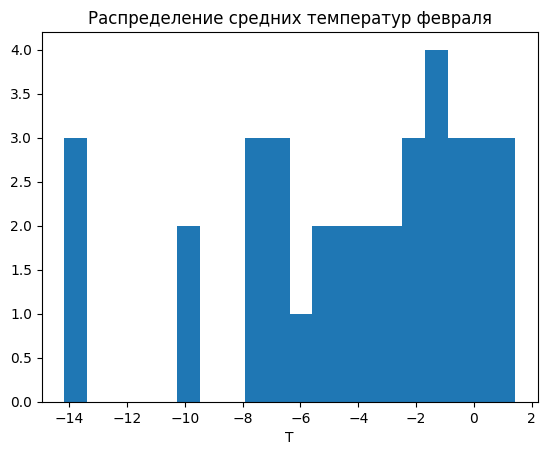

count    36.000000
mean     -4.244210
std       4.350577
min     -14.176562
25%      -6.741562
50%      -3.199589
75%      -1.013131
max       1.432292
Name: avg_temperature, dtype: float64

In [44]:
february_temps = decade_df[decade_df["month"] == 2]["avg_temperature"]

plt.hist(february_temps, bins=20)
plt.title("Распределение средних температур февраля")
plt.xlabel("T")
plt.show()

february_temps.describe()

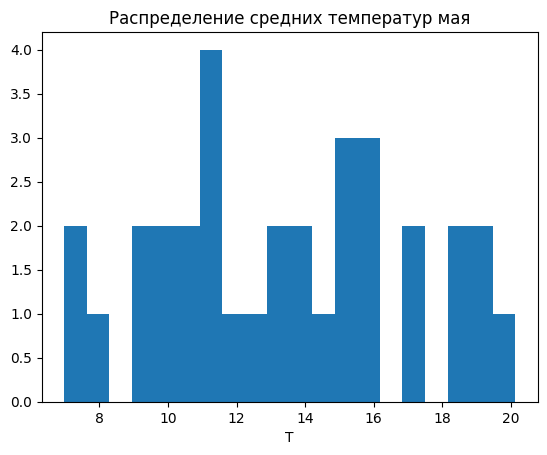

count    33.000000
mean     13.376175
std       3.617134
min       6.975000
25%      10.835227
50%      13.368750
75%      15.867045
max      20.125000
Name: avg_temperature, dtype: float64

In [45]:
may_temps = decade_df[decade_df["month"] == 5]["avg_temperature"]

plt.hist(may_temps, bins=20)
plt.title("Распределение средних температур мая")
plt.xlabel("T")
plt.show()

may_temps.describe()

In [46]:
decade_df.to_csv(DATA_PROCESSED / "decades.csv", index=False)